In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [2]:
nShotUnit = 1
epsilon = 0.001
alpha = 0.05

In [3]:
pTrue = 0.2505
thetaTrue = np.arcsin(np.sqrt(pTrue))

In [4]:
# 次のroundに行く場合はNaNとする
nEstim = 10000
minRatio = 2
#nGrovers = np.arange(200, 701, 10)
nGrovers = [300]
angleFracs = np.linspace(0, 1, num=42)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2, endCriterion="Angle")
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

300 0.024390243902439025 2023-11-06 10:18:25.417771
300 0.04878048780487805 2023-11-06 10:18:26.272834
300 0.07317073170731708 2023-11-06 10:18:27.010038
300 0.0975609756097561 2023-11-06 10:18:27.730374
300 0.12195121951219512 2023-11-06 10:18:28.539077
300 0.14634146341463417 2023-11-06 10:18:29.448185
300 0.17073170731707318 2023-11-06 10:18:30.413211
300 0.1951219512195122 2023-11-06 10:18:31.514453
300 0.21951219512195122 2023-11-06 10:18:32.752317
300 0.24390243902439024 2023-11-06 10:18:34.071238
300 0.2682926829268293 2023-11-06 10:18:35.496959
300 0.29268292682926833 2023-11-06 10:18:36.978421
300 0.3170731707317073 2023-11-06 10:18:38.463041
300 0.34146341463414637 2023-11-06 10:18:39.876006
300 0.36585365853658536 2023-11-06 10:18:41.079076
300 0.3902439024390244 2023-11-06 10:18:42.182669
300 0.41463414634146345 2023-11-06 10:18:43.300422
300 0.43902439024390244 2023-11-06 10:18:44.334350
300 0.4634146341463415 2023-11-06 10:18:45.246816
300 0.4878048780487805 2023-11-06 10

In [5]:
#resDf.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.2505_nG200-700.csv", index=False)

In [6]:
resDf[resDf['nGrover'] == 300]

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,300.0,100.0,0.024390,-0.000098,10000.0,10000.0
1,300.0,100.0,0.048780,-0.000174,10000.0,10000.0
2,300.0,100.0,0.073171,-0.000232,10000.0,10000.0
3,300.0,100.0,0.097561,-0.000267,10000.0,10000.0
4,300.0,100.0,0.121951,-0.000278,10000.0,10000.0
5,300.0,100.0,0.146341,-0.000279,10000.0,10000.0
6,300.0,100.0,0.170732,-0.000250,10000.0,10000.0
7,300.0,100.0,0.195122,-0.000199,10000.0,10000.0
8,300.0,100.0,0.219512,-0.000116,10000.0,10000.0
9,300.0,100.0,0.243902,-0.000015,10000.0,10000.0


In [7]:
resDf

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,300.0,100.0,0.024390,-0.000098,10000.0,10000.0
1,300.0,100.0,0.048780,-0.000174,10000.0,10000.0
2,300.0,100.0,0.073171,-0.000232,10000.0,10000.0
3,300.0,100.0,0.097561,-0.000267,10000.0,10000.0
4,300.0,100.0,0.121951,-0.000278,10000.0,10000.0
5,300.0,100.0,0.146341,-0.000279,10000.0,10000.0
6,300.0,100.0,0.170732,-0.000250,10000.0,10000.0
7,300.0,100.0,0.195122,-0.000199,10000.0,10000.0
8,300.0,100.0,0.219512,-0.000116,10000.0,10000.0
9,300.0,100.0,0.243902,-0.000015,10000.0,10000.0


In [8]:
resDf["Bias"]

0    -0.000098
1    -0.000174
2    -0.000232
3    -0.000267
4    -0.000278
5    -0.000279
6    -0.000250
7    -0.000199
8    -0.000116
9    -0.000015
10    0.000081
11    0.000165
12    0.000231
13    0.000270
14    0.000279
15    0.000276
16    0.000253
17    0.000207
18    0.000140
19    0.000052
20   -0.000053
21   -0.000139
22   -0.000208
23   -0.000248
24   -0.000272
25   -0.000275
26   -0.000273
27   -0.000222
28   -0.000169
29   -0.000074
30    0.000032
31    0.000109
32    0.000194
33    0.000248
34    0.000274
35    0.000288
36    0.000268
37    0.000228
38    0.000172
39    0.000099
Name: Bias, dtype: float64

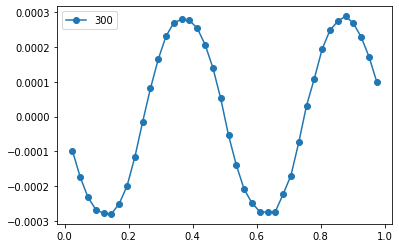

In [9]:
ax = plt.gca()
for nG in [300]:
    resDfPart = resDf[resDf["nGrover"] == nG]
    plt.plot(resDfPart["AngleFrac"], resDfPart["Bias"], label=str(nG), marker="o")
plt.legend()
plt.show()